In [1]:
import pandas as pd
import matplotlib.pyplot as plt


In [2]:
#load data
emissions_by_country = pd.read_csv("annual-co2-emissions-per-country.csv")
country_pop = pd.read_csv("population.csv")
hdi = pd.read_csv("human-development-index.csv")

In [3]:
#Filter to year 2023
emissions_2023 = emissions_by_country[emissions_by_country["Year"] == 2023].copy()
pop_2023 = country_pop[country_pop["Year"] == 2023].copy()
hdi_2023 = hdi[hdi["Year"] == 2023].copy()

#filter out non-countries (i.e. blocs/regions) by removing those without a "Code" abbreviation
emissions_2023 = emissions_2023[emissions_2023["Code"].notna()].copy()
pop_2023 = pop_2023[pop_2023["Code"].notna()].copy()
hdi_2023 = hdi_2023[hdi_2023["Code"].notna()].copy()

#Strip out unnecessary columns
emissions_2023 = emissions_2023[["Entity", "Code", "Annual CO₂ emissions"]]
pop_2023 = pop_2023[["Entity", "Code", "Population"]]
hdi_2023 = hdi_2023[["Entity", "Code", "Human Development Index", "World region according to OWID"]]

In [4]:

#Merge the existing dfs into one combined df. Inner merge to keep the countries consistent (merges what is common)

combined_df = emissions_2023.merge(pop_2023, on = "Code", how = "inner")
combined_df = combined_df.merge(hdi_2023, on = "Code", how = "inner")


In [5]:
#Rename Entity X to Country and drop entity_y as it's redundant
combined_df = combined_df.rename(columns={"Entity_x": "Country"})
combined_df = combined_df.drop(columns=["Entity_y", "Entity"])

In [6]:
#Calculate CO2 per capita metric

combined_df["co2_per_capita"] = combined_df["Annual CO₂ emissions"] / combined_df["Population"]


In [7]:
#Drop missing/incomplete values

combined_df = combined_df.dropna(subset=["co2_per_capita", "Human Development Index"])

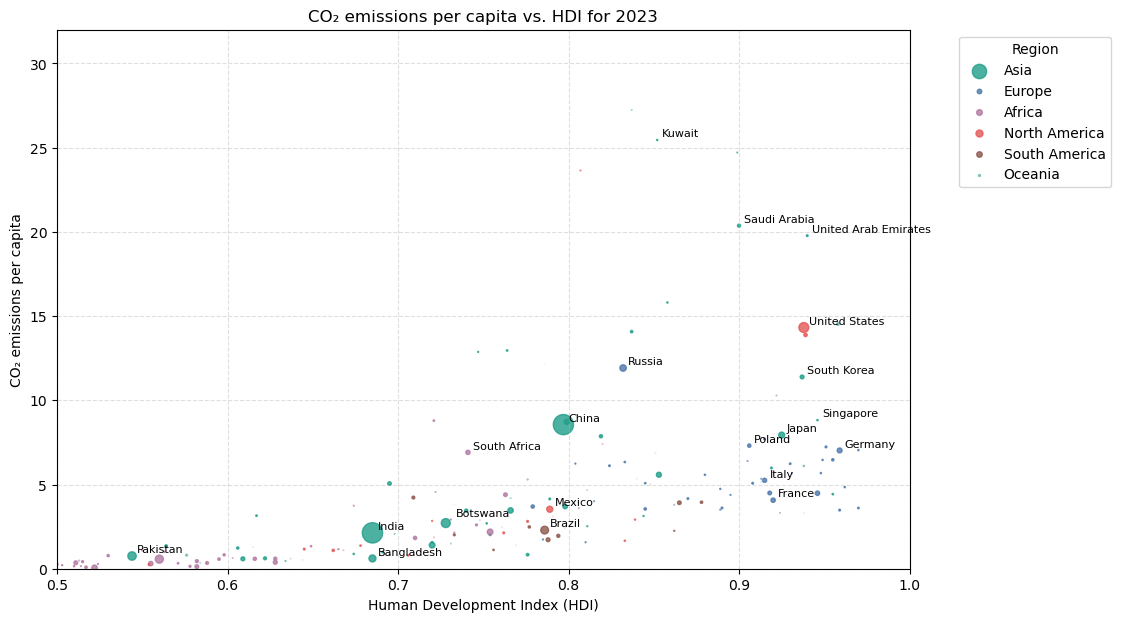

In [8]:
#Create the visualization

visualization_df = combined_df.copy()

#Set the size of each dot to represent raw population of country
visualization_df["bubble_size"] = visualization_df["Population"] / visualization_df["Population"].max() * 1200

#set the plot size
plt.figure(figsize=(11, 7))

#Grab a list of the unique geographic regions (Asia, North America, Europe, etc...)

regions = visualization_df["World region according to OWID"].dropna().unique()

#Setup the color legend for each country's region like in the OWID visualization:

color_map = {
    "Asia": "#1f9e89",         
    "Europe": "#4c78a8",        
    "Africa": "#b279a2",        
    "North America": "#e45756", 
    "South America": "#8c564b", 
    "Oceania": "#72b7b2"        
}

#Plot the CO2 vs HDI points, by region, for all the countries (distinguishes regions by color)
for region in regions:
    
    region_info = visualization_df[visualization_df["World region according to OWID"] == region]
    plt.scatter(
        region_info["Human Development Index"],
        region_info["co2_per_capita"],
        s = region_info["bubble_size"],
        alpha = 0.8,
        label = region,
        #maps colors to each region appropriately, and uses grey as a fall back
        color = color_map.get(region, "grey")
    )

plt.xlabel("Human Development Index (HDI)")
plt.ylabel("CO₂ emissions per capita")
plt.title("CO₂ emissions per capita vs. HDI for 2023")

#add grid lines for visual clarity
plt.grid(True, linestyle="--", alpha=0.4)


#Anchor the legend to the upper left part just outside the top right of the actual plot
plt.legend(title="Region", bbox_to_anchor=(1.05, 1), loc="upper left")

#Create a list to label several countries to recreate the original labeling scheme (slight difference as original had you display labels by region)
countries_w_label = [
    "United States", "Mexico", "China", "India", "Italy", "Poland", "Singapore",
    "Kuwait", "United Arab Emirates", "Saudi Arabia",
    "Germany", "South Africa", "Japan", "France", "Brazil", "Russia",
    "South Korea", "Pakistan", "Botswana", "Bangladesh",
]

#label the above country datapoints
for country in countries_w_label:

    #grab data for each country
    country_row = visualization_df[visualization_df["Country"] == country]

    #this if loop ensures that the program won't crash if a value is missing
    if not country_row.empty:
        #grab the HDI value
        x = country_row["Human Development Index"].values[0]

        #grab the CO2 per capita value
        y = country_row["co2_per_capita"].values[0]

        #Plot the label at the right point (slight shifted above to the right)
        plt.text(x + 0.003, y + 0.2, country, fontsize=8)

#Limits the axis sizes to roughly match the default OWID visualization's
plt.xlim(0.5, 1.0)
plt.ylim(0, 32)
plt.show()

In [9]:
correlation = combined_df["Human Development Index"].corr(combined_df["co2_per_capita"])
#This value shows the correlation coefficient between HDI and CO2 emissions per capita 
print("Correlation:", correlation)

Correlation: 0.537284409478381


In [10]:
combined_df.to_csv("final_dataset.csv", index=False)